# UCI HAR Dataset 기반 SENet 분류

### 결과 분석
```
Test accuracy: 95.11%
```
SENet 기반 모델은 UCI HAR 데이터셋에서 test accuracy 95.11%으로 중요한 feature channel을 강조해 전체적으로 높은 성능을 보였지만 sitting과 standing처럼 센서 변화가 작고 서로 유사한 정적 활동에서는 여전히 혼동이 발생했다.

sitting과 standing의 차이가 큰 움직임 패턴보다는 자세 방향, 중력 성분, 센서 축의 미세한 차이에서 나타나지만 SE Block은 Global Average Pooling을 통해 시간축 정보를 평균화한 뒤 channel attention을 계산하므로 이러한 미세한 정적 자세 차이가 attention 과정에서 약화될 수 있다.


따라서 SENet은 동적 활동 분류에는 효과적이지만 유사한 정적 자세를 명확히 구분하기 위해 temporal attention 구조가 필요하다고 판단된다.

In [29]:
# 라이브러리 import
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, GaussianNoise,
    Multiply, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

In [30]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST = "test/"

INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [32]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        signal_data = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row = row.replace('  ', ' ').strip().split(' ')
                row = [np.float32(x) for x in row]
                signal_data.append(row)

        X_signals.append(signal_data)

    X_signals = np.array(X_signals)

    # (9, samples, 128) -> (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))

In [33]:
# y 데이터 로드 함수
def load_y(y_path):
    y = []
    with open(y_path, 'r') as file:
        for row in file:
            y.append(int(row.strip()))

    y = np.array(y, dtype=np.int32)
    return y - 1  # 1~6 -> 0~5

In [34]:
# 데이터 로드
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test  = load_X(X_test_signals_paths)
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
y_test  = load_y(DATASET_PATH + TEST  + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:",  y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [35]:
# 데이터 표준화
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

In [36]:
# One-hot 인코딩
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=6)
y_test_onehot  = tf.keras.utils.to_categorical(y_test,  num_classes=6)

print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:",  y_test_onehot.shape)

y_train_onehot shape: (7352, 6)
y_test_onehot shape: (2947, 6)


## SE Block (Squeeze-and-Excitation Block)
채널별 중요도를 학습해서 중요한 채널은 강조하고, 불필요한 채널은 억제하는 채널 어텐션 구조

### 동작 과정
1. **Squeeze** : GlobalAveragePooling으로 각 채널의 전체 시간 정보를 하나의 값으로 압축
2. **Excitation** : 두 개의 Dense 레이어로 채널 간 관계를 학습해 각 채널의 가중치(0~1)를 계산
   - 첫 번째 Dense:  모든 채널 정보를 그대로 사용하지 않고 채널 수를 줄여 핵심 정보만 압축
   - 두 번째 Dense: 원래 채널 수로 복원 후 sigmoid로 0~1 사이 가중치 출력
3. **Scale** : 학습된 가중치를 원래 특징 맵에 곱해 채널별로 재조정

### 사용 목적
CNN이 추출한 특징 중 행동 분류에 더 유용한 센서 채널 패턴을 동적으로 강조하기 위해 사용

### 사용 이유
가속도, 자이로 등 9개 센서 채널의 중요도가 행동마다 다르기 때문에 SE Block이 매 레이어마다 현재 특징에 맞는 채널 가중치를 학습해 분류 성능을 높임

In [37]:
# SE Block 정의
def se_block(x, ratio=16):
    channels = x.shape[-1]
    reduction = max(channels // ratio, 1)

    # Squeeze: 각 채널의 시간 전체를 평균 → (batch, channels)
    se = GlobalAveragePooling1D()(x)

    # Excitation: 채널 간 관계 학습
    se = Dense(reduction, activation='relu',    use_bias=False)(se)
    se = Dense(channels,  activation='sigmoid', use_bias=False)(se)

    # Scale: (batch, channels) → (batch, 1, channels) 후 원래 특징 맵에 곱함
    se = Reshape((1, channels))(se)
    return Multiply()([x, se])

## Conv-SE Block
두 번의 Conv 연산으로 시간 패턴을 추출한 뒤, SE Block으로 채널 중요도를 재조정

In [38]:
# Conv-SE Block 정의
def conv_se_block(x, filters, kernel_size=3, pool=True, ratio=16):
    # 첫 번째 Conv: 기본적인 시간 패턴 추출
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # 두 번째 Conv: 더 복잡한 특징 학습
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # SE Block: 채널 어텐션 적용
    x = se_block(x, ratio=ratio)

    if pool:
        x = MaxPooling1D(pool_size=2)(x)

    return x

In [39]:
def build_senet_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = GaussianNoise(0.01)(inputs)

    # 단일 초기 Conv
    x = Conv1D(64, kernel_size=5, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Conv-SE Blocks
    x = conv_se_block(x, filters=64,  kernel_size=3, pool=True,  ratio=16)
    x = conv_se_block(x, filters=128, kernel_size=3, pool=True,  ratio=16)
    x = conv_se_block(x, filters=128, kernel_size=3, pool=False, ratio=16)

    # Pooling
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    # Classifier
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [40]:
# 모델 생성 및 컴파일
input_shape = (X_train.shape[1], X_train.shape[2])  # (128, 9)
num_classes = 6

model = build_senet_model(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 128, 9)    │          0 │ input_layer_1[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 128, 64)   │      2,880 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 128, 64)   │     12,288 │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 128, 64)   │     12,288 │ re_lu_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_9[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 4)         │        256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │        256 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 64)     │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 128, 64)   │          0 │ re_lu_9[0][0],    │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 64, 64)    │          0 │ multiply_3[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 64, 128)   │     24,576 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 64, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 240,582 (939.77 KB)

 Trainable params: 239,174 (934.27 KB)

 Non-trainable params: 1,408 (5.50 KB)

In [41]:
# Callback 설정
callbacks = [
    ModelCheckpoint(
        "UCI_HAR_SENET_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

In [42]:
# 모델 학습
history = model.fit(
    X_train, y_train_onehot,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6781 - loss: 0.9790
Epoch 1: val_accuracy improved from None to 0.34874, saving model to UCI_HAR_SENET_best.keras

Epoch 1: finished saving model to UCI_HAR_SENET_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.8308 - loss: 0.5988 - val_accuracy: 0.3487 - val_loss: 1.6658 - learning_rate: 3.0000e-04
Epoch 2/100
85/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9477 - loss: 0.2558
Epoch 2: val_accuracy improved from 0.34874 to 0.50170, saving model to UCI_HAR_SENET_best.keras

Epoch 2: finished saving model to UCI_HAR_SENET_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9500 - loss: 0.2450 - val_accuracy: 0.5017 - val_loss: 1.1247 - learning_rate: 3.0000e-04
Epoch 3/100
86/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9565 - loss: 0.2382
Epoch 3: val_accuracy improved from 0.50170 to 0.93746, saving model to UCI_HAR_SENET_best.keras

Epoch 3: finished saving model to UCI_HAR_SENE

In [43]:
model = tf.keras.models.load_model("UCI_HAR_SENET_best.keras")

In [44]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test_onehot,  verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 98.57%
Training loss: 0.1681
Test accuracy: 95.11%
Test loss: 0.2630


In [45]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9958    0.9657    0.9806       496
           1     0.9933    0.9490    0.9707       471
           2     0.9190    1.0000    0.9578       420
           3     0.9573    0.8228    0.8850       491
           4     0.8672    0.9699    0.9157       532
           5     0.9908    1.0000    0.9954       537

    accuracy                         0.9511      2947
   macro avg     0.9539    0.9513    0.9509      2947
weighted avg     0.9539    0.9511    0.9508      2947



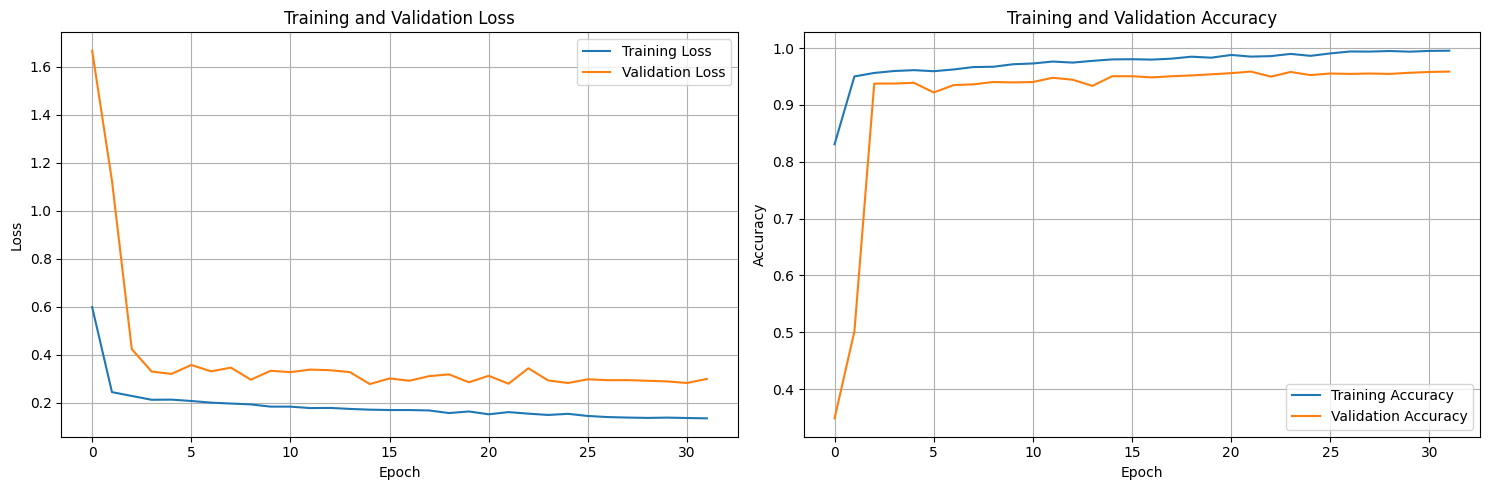

In [46]:
# 학습 곡선 시각화
train_loss     = history.history['loss']
val_loss       = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy   = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss,   label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy,   label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

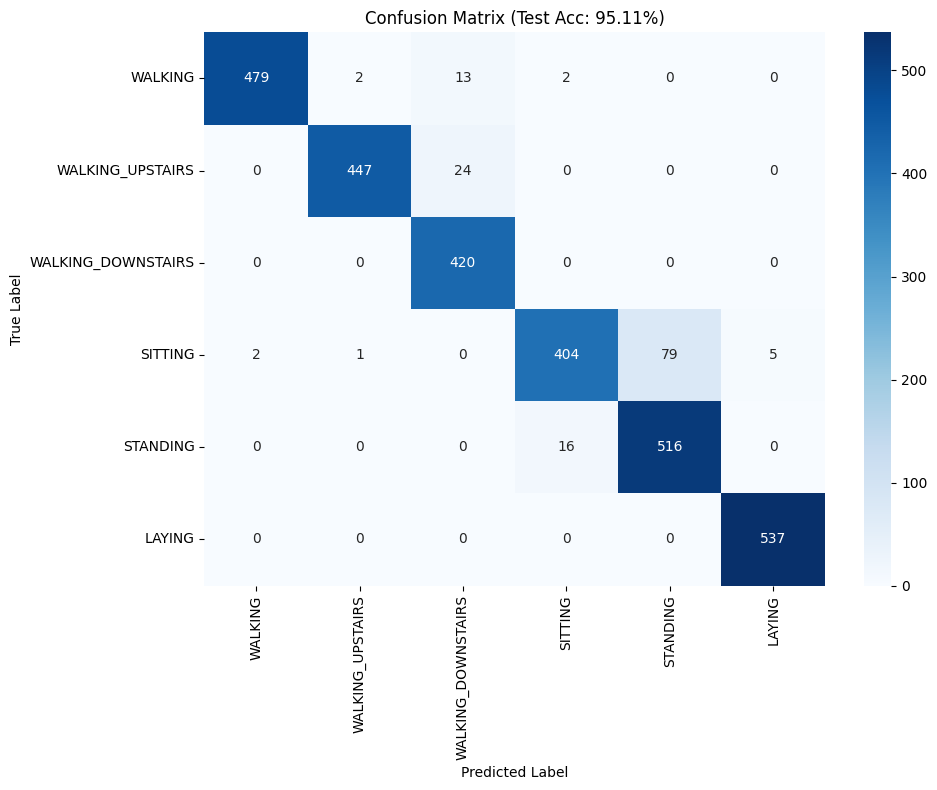

In [47]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()